In [27]:
import pandas as pd

df = pd.read_csv(r"C:\Users\YEADONAY\Downloads\raw_analyst_ratings.csv")
print(df.head())


   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-06-03 10:45:20-04:00     A  
2  2020-05-26 04:30:07-04:00 

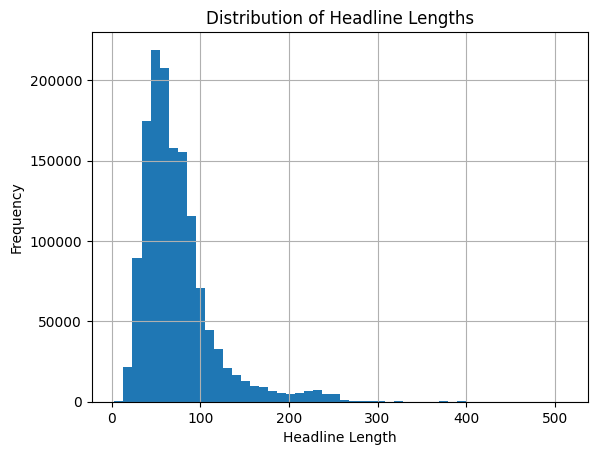

In [21]:
df['headline_length'] = df['headline'].apply(len)

# Plot
df['headline_length'].hist(bins=50)
plt.title("Distribution of Headline Lengths")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")
plt.show()

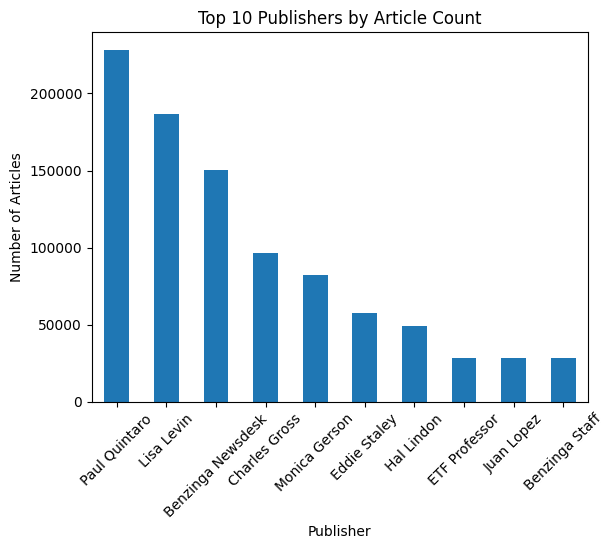

In [22]:
top_publishers = df['publisher'].value_counts().head(10)
top_publishers.plot(kind='bar')
plt.title("Top 10 Publishers by Article Count")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()


In [37]:


print(df.columns)


Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'stock',
       'headline_length'],
      dtype='object')


In [39]:

df = pd.read_csv(r"C:\Users\YEADONAY\Downloads\raw_analyst_ratings.csv")
print(df.columns)

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='object')


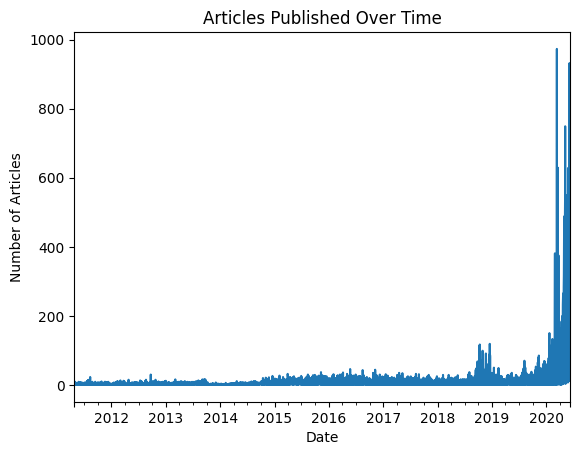

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv('C:/Users/YEADONAY/Downloads/raw_analyst_ratings.csv')

# Convert 'date' column to datetime, let pandas infer timezone info
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop rows where 'date' couldn't be parsed
df = df.dropna(subset=['date'])

# Set 'date' as index
df.set_index('date', inplace=True)

# Resample by day and plot count of articles
df.resample('D').size().plot()

plt.title("Articles Published Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()


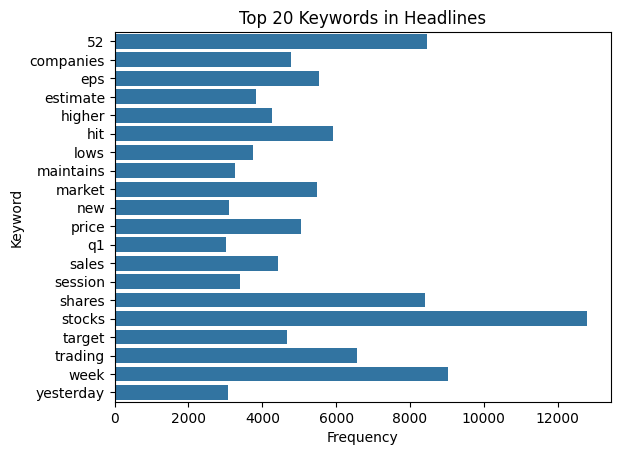

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(df['headline'])
word_freq = X.toarray().sum(axis=0)
words = vectorizer.get_feature_names_out()

# Plot
sns.barplot(x=word_freq, y=words)
plt.title("Top 20 Keywords in Headlines")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.show()


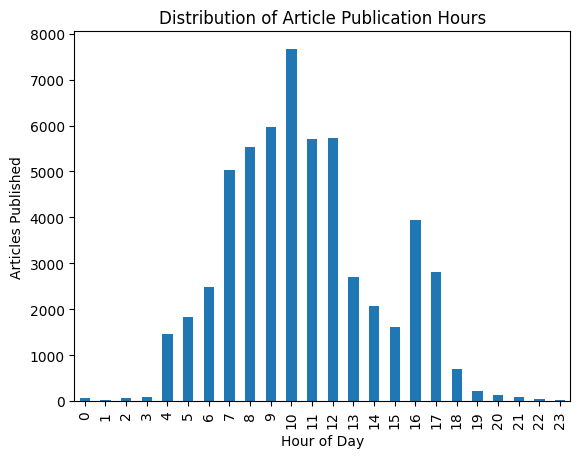

In [7]:
df['hour'] = df.index.hour
df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Article Publication Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Articles Published")
plt.show()


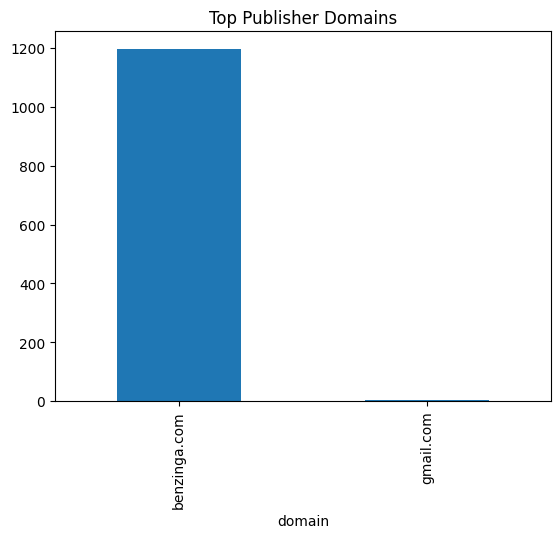

In [10]:
df['domain'] = df['publisher'].str.extract(r'@(\w+\.\w+)$')
df['domain'].value_counts().head(10).plot(kind='bar')
plt.title("Top Publisher Domains")
plt.show()


In [13]:

# Plotting code
%matplotlib inline
import matplotlib.pyplot as plt

def plot_tech_indicators(df):
    fig, axes = plt.subplots(3, 1, figsize=(10,12))
    
    # Plot 1
    axes[0].plot(df['Close'], label='Price')
    axes[0].set_title('Price')
    
    # Plot 2
    axes[1].plot(df['RSI'], label='RSI')
    axes[1].set_title('RSI')
    
    # Plot 3
    axes[2].plot(df['MACD'], label='MACD')
    axes[2].set_title('MACD')
    
    plt.tight_layout()
    plt.savefig('technical_analysis.png')
    plt.show()

# Example usage (uncomment to run)
# plot_tech_indicators(sample_data)